In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
sfreq = 32
paradigm = P300(resample=sfreq, tmin=-0.2, tmax=2, fmin=0.5, fmax=16)
dataset = EPFLP300()

In [3]:
subject, session, run = 2, "session_1", "run_1"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Not setting metadata
134 matching events found
No baseline correction applied


Number of events,134
Events,NonTarget: 112Target: 22
Time range,-0.188 – 1.969 sec
Baseline,off


No projector specified for this dataset. Please consider the method self.add_proj.


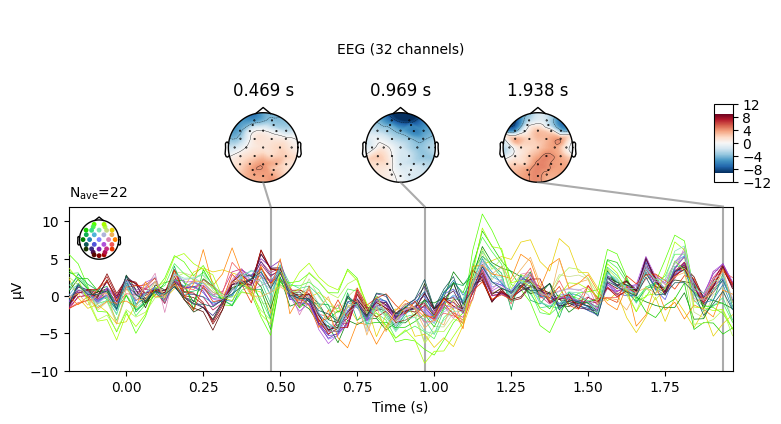

No projector specified for this dataset. Please consider the method self.add_proj.


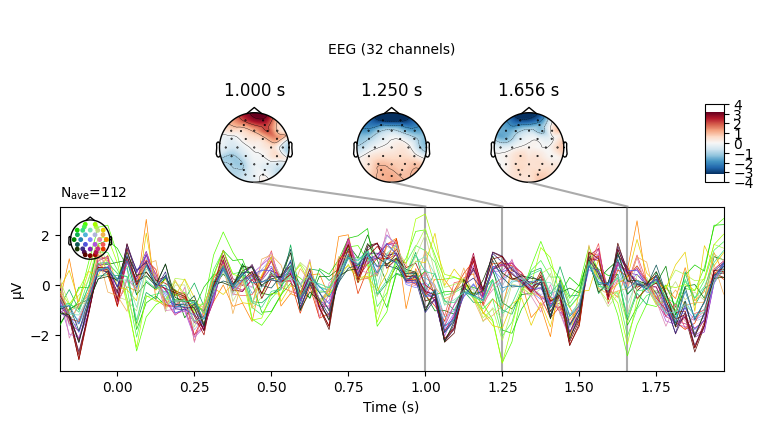

No projector specified for this dataset. Please consider the method self.add_proj.


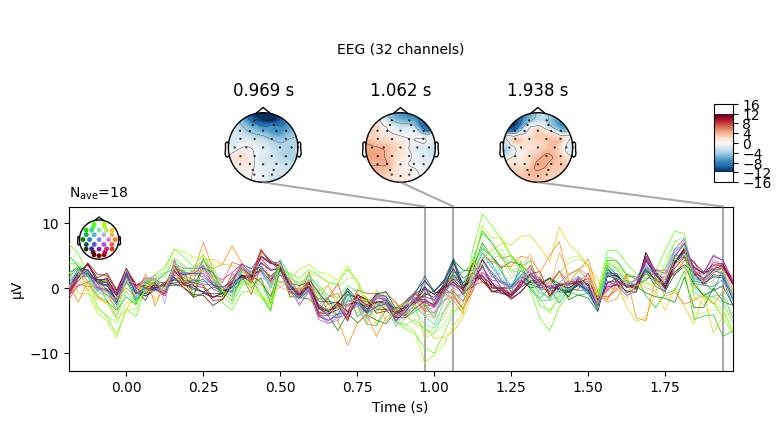

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
_ = target.plot_joint()
non_target = epochs['NonTarget'].average()
_ = non_target.plot_joint()
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint()

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [6]:
roi0 = int((0 - epochs.tmin)*epochs.info['sfreq'])
roi1 = int((0.2 - epochs.tmin)*epochs.info['sfreq'])
n_times = roi1-roi0
n_epochs = len(epochs)
n_channels = len(epochs.ch_names)
n_lags= int(0.5*sfreq)
X = np.zeros((n_epochs, n_channels, n_times, n_lags))

for l in range(n_lags):
    X[:,:,:,l] = epochs.get_data()[:,:,roi0+l:roi1+l]
print(X.shape)

(134, 32, 6, 16)


In [7]:
split = len(epochs)//2
X_train = X[:split]
X_test = X[split:]
labels_train = labels[:split]
labels_test = labels[split:]
y_train = labels_train
y_test = labels_test


In [8]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl


X_train /= np.std(X_train, axis=0)[np.newaxis,:,:]
X_test /= np.std(X_train, axis=0)[np.newaxis,:,:]

#X_train, factors = tensorly.decomposition.partial_tucker(X_train, modes=(1,2,3), rank=None)
#X_test = tensorly.tenalg.multi_mode_dot(X_test, factors, modes=(1,2,3), transpose=True)
factors = [tl.eye(X_train.shape[1]),tl.eye(X_train.shape[2]),tl.eye(X_train.shape[3])]


#plt.semilogy(np.mean(np.abs(X_train), axis=(0,2,3)), label='space')
#plt.semilogy(np.mean(np.abs(X_train), axis=(0,1,3)), label='time')
#plt.semilogy(np.mean(np.abs(X_train), axis=(0,1,2)), label='lag')

#plt.legend()

In [9]:
import tensorly as tl
try:
    tl.set_backend('jax')
except AttributeError:
    tl.set_backend('jax')

In [10]:
tl.SVD_FUNS

{'numpy_svd': <bound method Backend.partial_svd of TensorLy jax-backend>,
 'truncated_svd': <bound method Backend.truncated_svd of TensorLy jax-backend>,
 'symeig_svd': <bound method Backend.symeig_svd of TensorLy jax-backend>,
 'randomized_svd': <bound method Backend.randomized_svd of TensorLy jax-backend>}

In [11]:
hoda = HODA(max_iter=128, rank=4, tol=1e-6,
            initialize ='svd', verbose=True,
            shrinkage='oas', toeplitz=(1,2))
# %lprun -f tl_toeplitz hoda.fit(X_train,y_train)
hoda.fit(X_train,y_train)

/home/arne/.virtualenvs/hoda-venv/lib/python3.10/site-packages/tensorly/backend/core.py:1106: UserWarning: In partial_svd: converting to NumPy. Check SVD_FUNS for available alternatives if you want to avoid this.
  warnings.warn('In partial_svd: converting to NumPy.'


[0/128]  shrinkage[0]=0.0687  shrinkage[1]=0.0622  shrinkage[2]=0.2157  step=2.8514e+00
[1/128]  shrinkage[0]=0.0557  shrinkage[1]=0.6698  shrinkage[2]=0.2954  step=2.6865e+00
[2/128]  shrinkage[0]=0.0693  shrinkage[1]=0.0481  shrinkage[2]=0.0958  step=2.6363e+00
[3/128]  shrinkage[0]=0.0564  shrinkage[1]=0.2994  shrinkage[2]=0.9228  step=2.9229e+00
[4/128]  shrinkage[0]=0.0705  shrinkage[1]=0.0459  shrinkage[2]=0.0997  step=2.7977e+00
[5/128]  shrinkage[0]=0.0568  shrinkage[1]=0.2796  shrinkage[2]=0.6742  step=2.6003e+00
[6/128]  shrinkage[0]=0.0701  shrinkage[1]=0.0447  shrinkage[2]=0.0833  step=2.3156e+00
[7/128]  shrinkage[0]=0.0574  shrinkage[1]=0.1298  shrinkage[2]=1.0000  step=2.2709e+00
[8/128]  shrinkage[0]=0.0700  shrinkage[1]=0.0456  shrinkage[2]=0.1021  step=2.1294e+00
[9/128]  shrinkage[0]=0.0599  shrinkage[1]=0.1093  shrinkage[2]=0.5047  step=1.7535e+00
[10/128]  shrinkage[0]=0.0684  shrinkage[1]=0.0496  shrinkage[2]=0.1455  step=1.6110e+00
[11/128]  shrinkage[0]=0.0603  

[93/128]  shrinkage[0]=0.0656  shrinkage[1]=0.0598  shrinkage[2]=0.5455  step=1.4370e+00
[94/128]  shrinkage[0]=0.0660  shrinkage[1]=0.0586  shrinkage[2]=0.4700  step=1.4370e+00
[95/128]  shrinkage[0]=0.0656  shrinkage[1]=0.0598  shrinkage[2]=0.5455  step=1.4370e+00
[96/128]  shrinkage[0]=0.0660  shrinkage[1]=0.0586  shrinkage[2]=0.4700  step=1.4370e+00
[97/128]  shrinkage[0]=0.0656  shrinkage[1]=0.0598  shrinkage[2]=0.5455  step=1.4370e+00
[98/128]  shrinkage[0]=0.0660  shrinkage[1]=0.0586  shrinkage[2]=0.4700  step=1.4370e+00
[99/128]  shrinkage[0]=0.0656  shrinkage[1]=0.0598  shrinkage[2]=0.5455  step=1.4370e+00
[100/128]  shrinkage[0]=0.0660  shrinkage[1]=0.0586  shrinkage[2]=0.4700  step=1.4370e+00
[101/128]  shrinkage[0]=0.0656  shrinkage[1]=0.0598  shrinkage[2]=0.5455  step=1.4370e+00
[102/128]  shrinkage[0]=0.0660  shrinkage[1]=0.0586  shrinkage[2]=0.4700  step=1.4370e+00
[103/128]  shrinkage[0]=0.0656  shrinkage[1]=0.0598  shrinkage[2]=0.5455  step=1.4370e+00
[104/128]  shrink

HODA(initialize='svd', max_iter=128, rank=4, toeplitz=(1, 2), tol=1e-06,
     verbose=True)

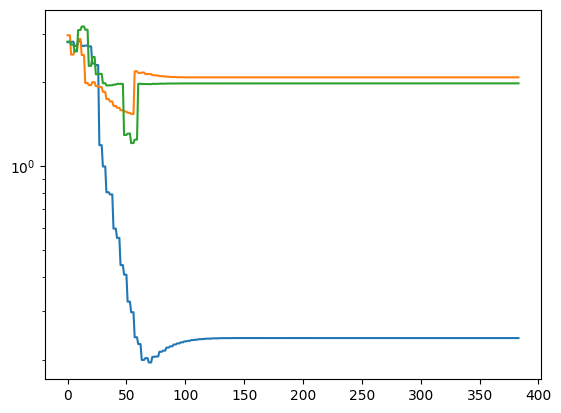

In [12]:
plt.semilogy(hoda.updates_[:,:hoda.iter_])
plt.show()

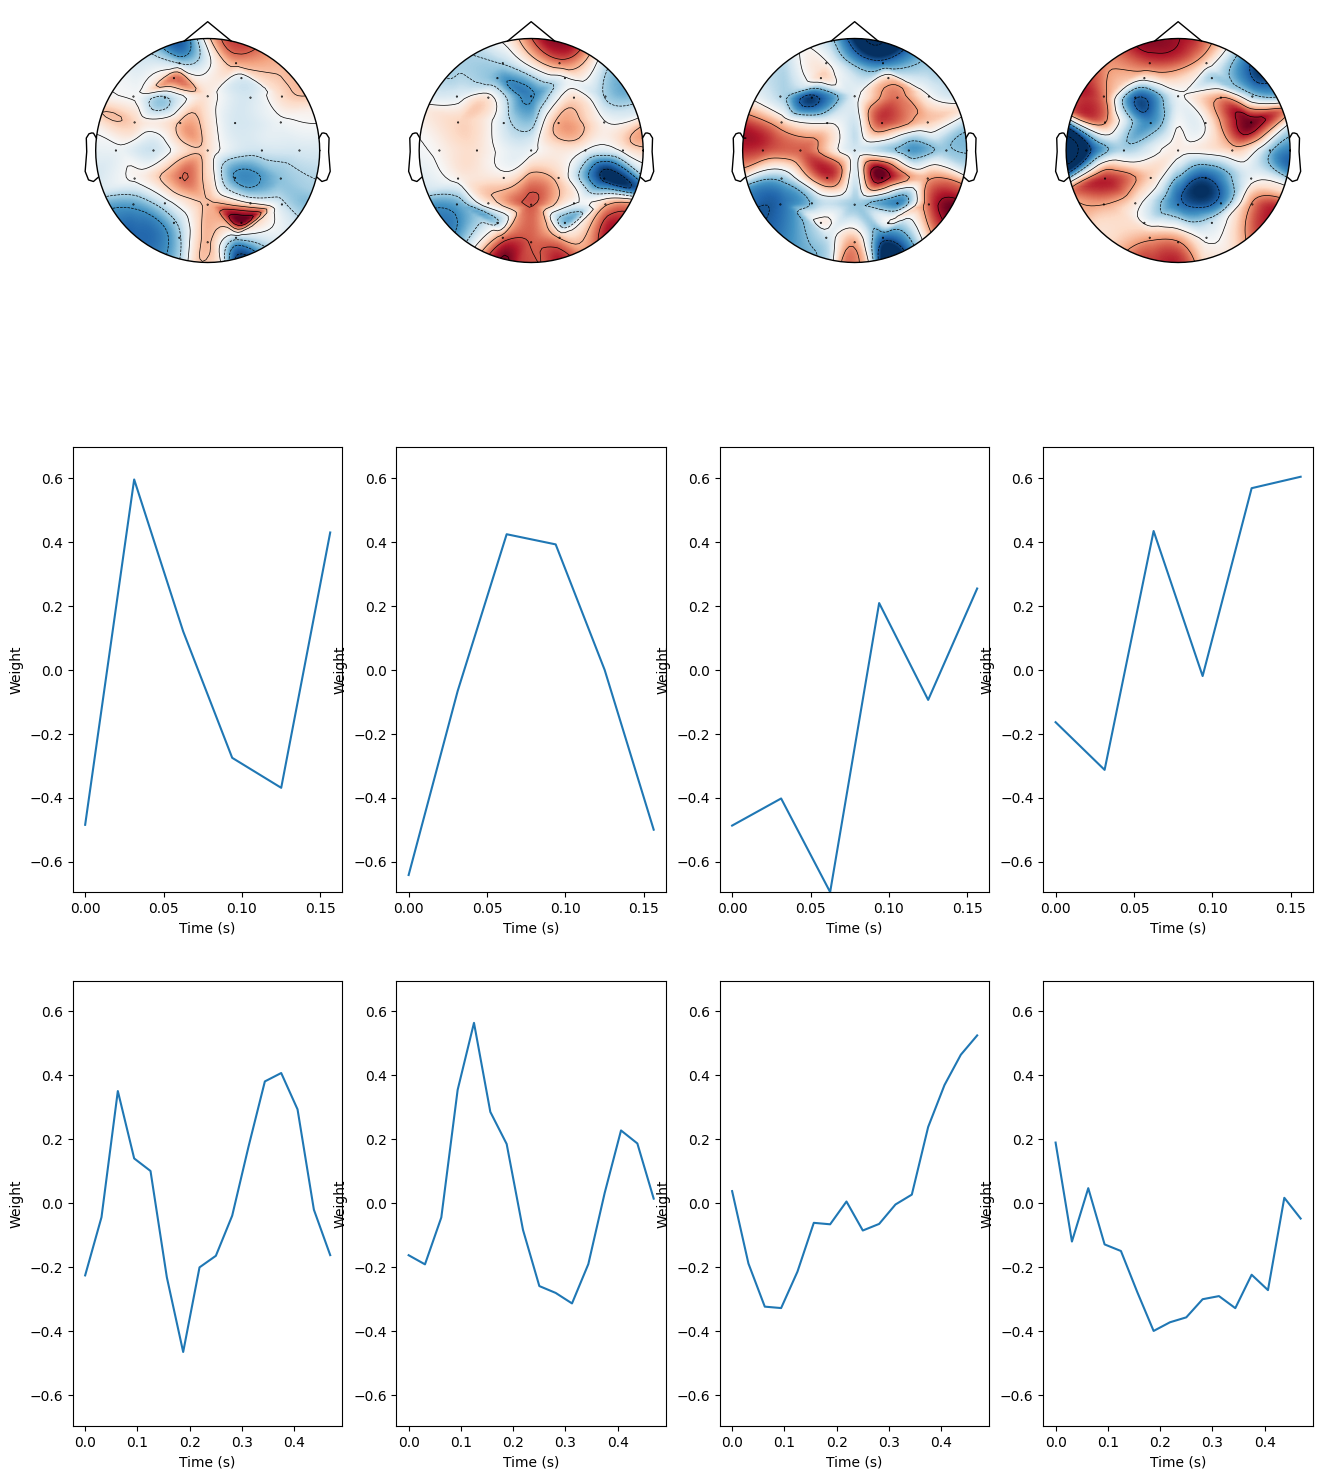

In [13]:

fig, axs = plt.subplots(3,hoda.rank, figsize=(16,6*3))
projs = [p for p in hoda.projs_]
for i in range(hoda.rank):
    w = projs[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(projs[1]))
for i in range(hoda.rank):
    w = projs[1][:,i]
    axs[1,i].plot(epochs.times[roi0:roi1], w)
    axs[1,i].set_xlabel('Time (s)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])
for i in range(hoda.rank):
    w = projs[2][:,i]
    axs[2,i].plot(np.arange(n_lags)/epochs.info['sfreq'], w)
    axs[2,i].set_xlabel('Time (s)')
    axs[2,i].set_ylabel('Weight')
    axs[2,i].set_ylim([-vmax, vmax])


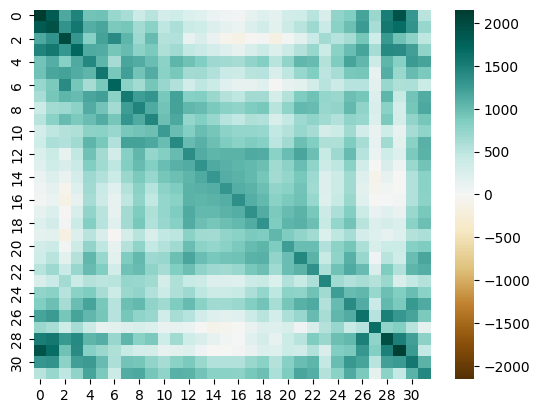

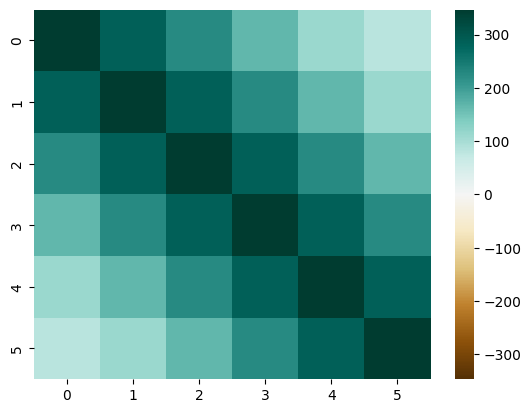

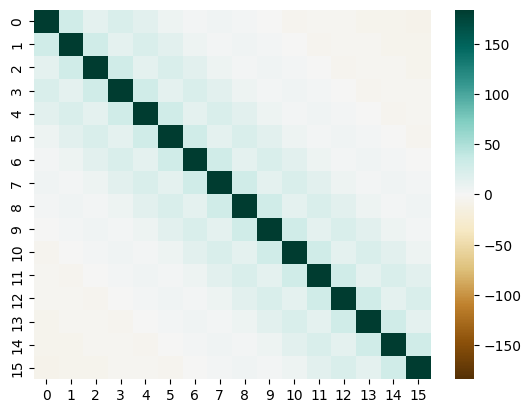

In [14]:
for k in range(3):
    cov = hoda.scatter_w_[k]
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

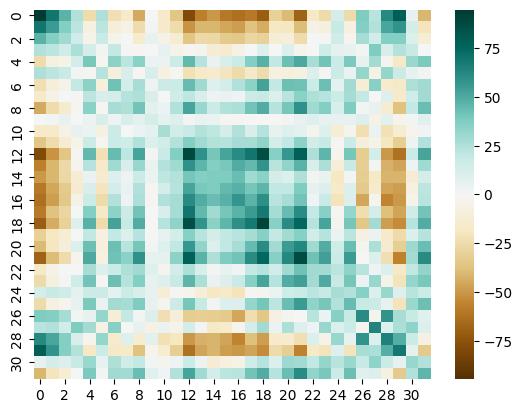

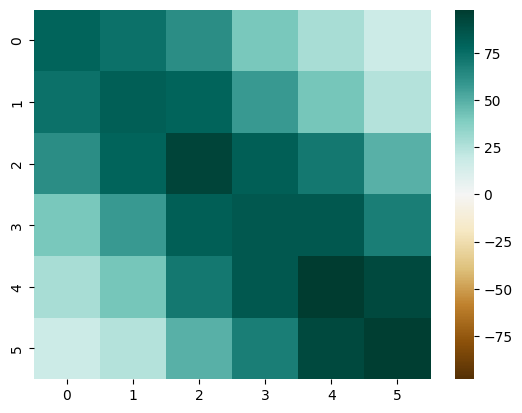

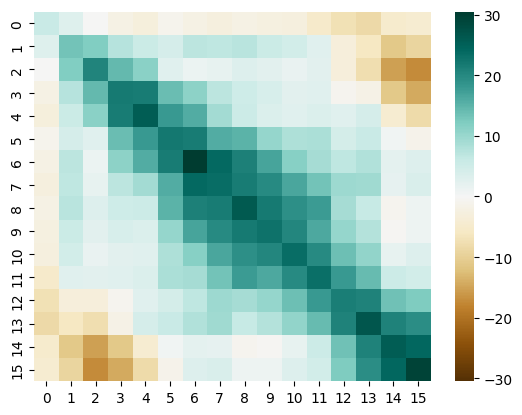

In [15]:
for k in range(3):
    cov = hoda.scatter_b_[k]
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

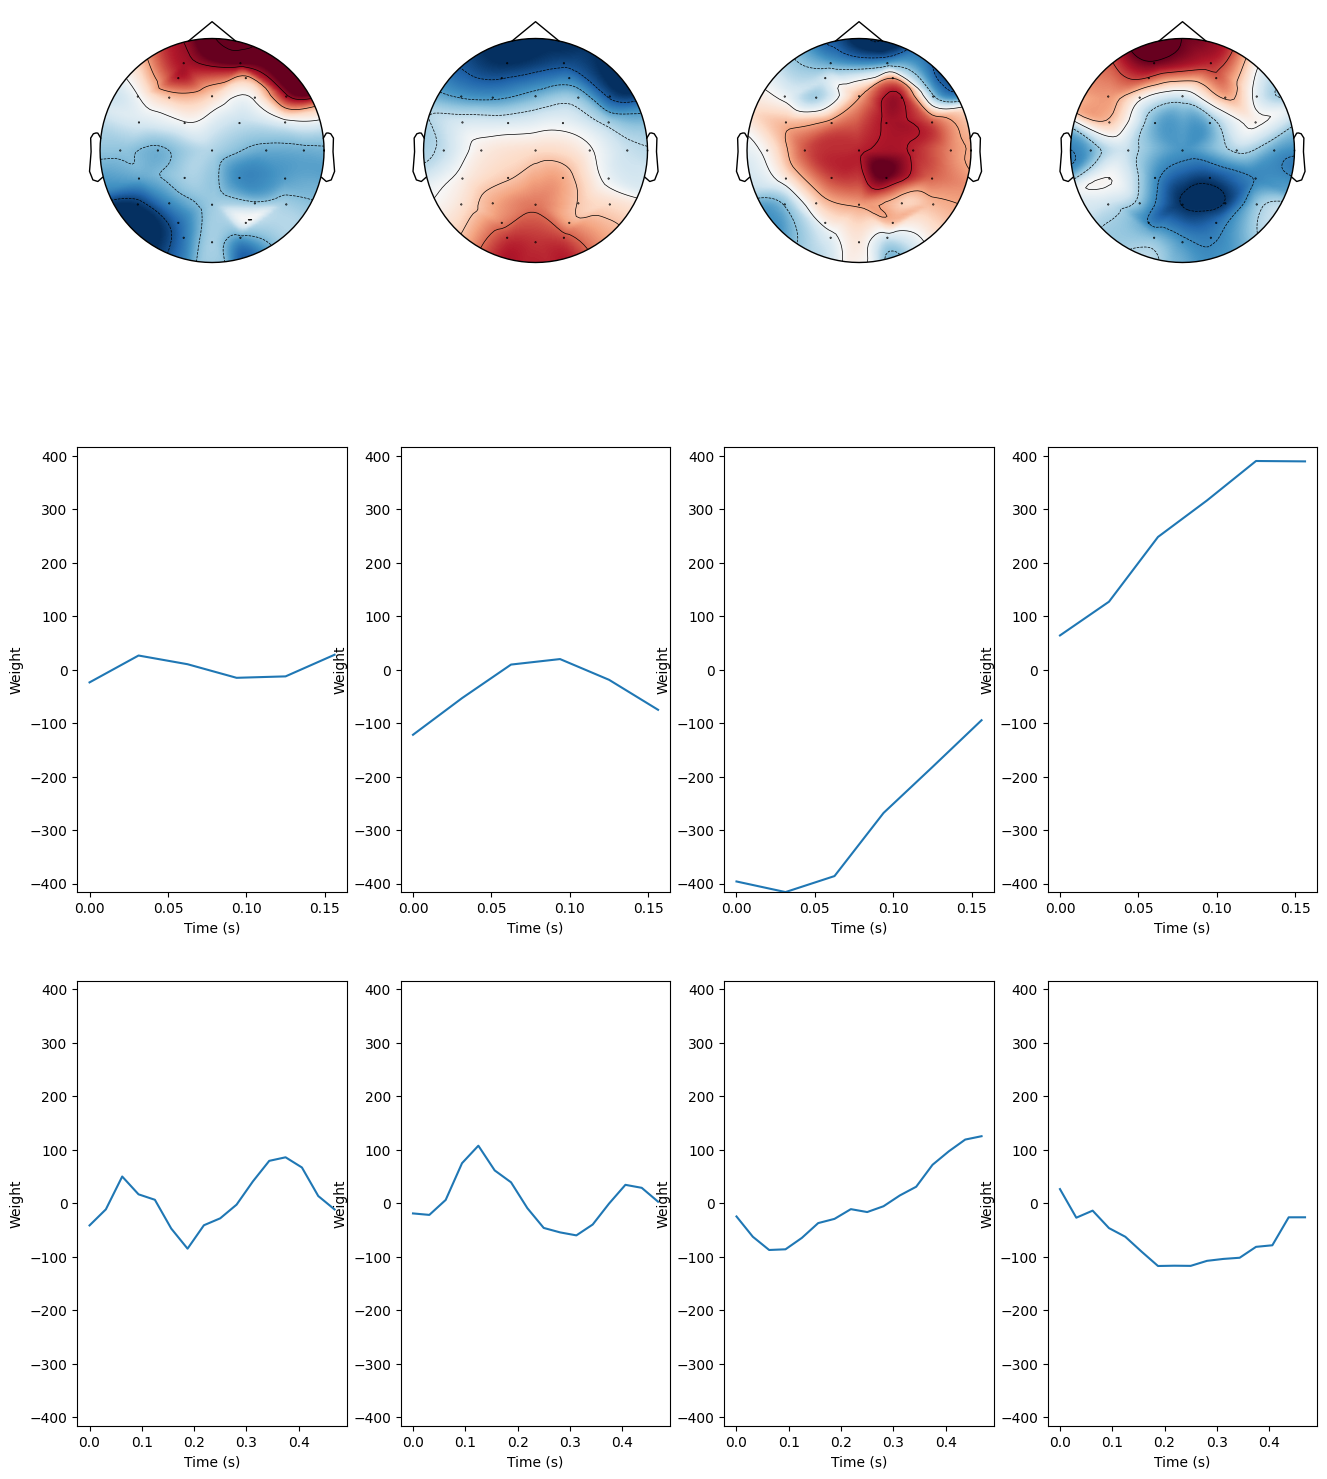

In [16]:
fig, axs = plt.subplots(3,hoda.rank, figsize=(16,6*3))
aps = [hoda.scatter_w_[k] @ p for k,p in enumerate(hoda.projs_)]
for i in range(hoda.rank):
    w = aps[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(aps[1]))
for i in range(hoda.rank):
    w = aps[1][:,i]
    axs[1,i].plot(epochs.times[roi0:roi1], w)
    axs[1,i].set_xlabel('Time (s)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])
for i in range(hoda.rank):
    w = aps[2][:,i]
    axs[2,i].plot(np.arange(n_lags)/epochs.info['sfreq'], w)
    axs[2,i].set_xlabel('Time (s)')
    axs[2,i].set_ylabel('Weight')
    axs[2,i].set_ylim([-vmax, vmax])

In [17]:
Xt_train = hoda.transform(X_train)
Xt_test = hoda.transform(X_test)
print(Xt_train.shape)
print(Xt_test.shape)

(67, 64)
(67, 64)


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

#classifier = LogisticRegression(penalty='l1', solver='liblinear')
classifier = LDA(solver='lsqr', shrinkage='auto')

classifier.fit(Xt_train,y_train)
classifier.fit(Xt_train,y_train)
feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()

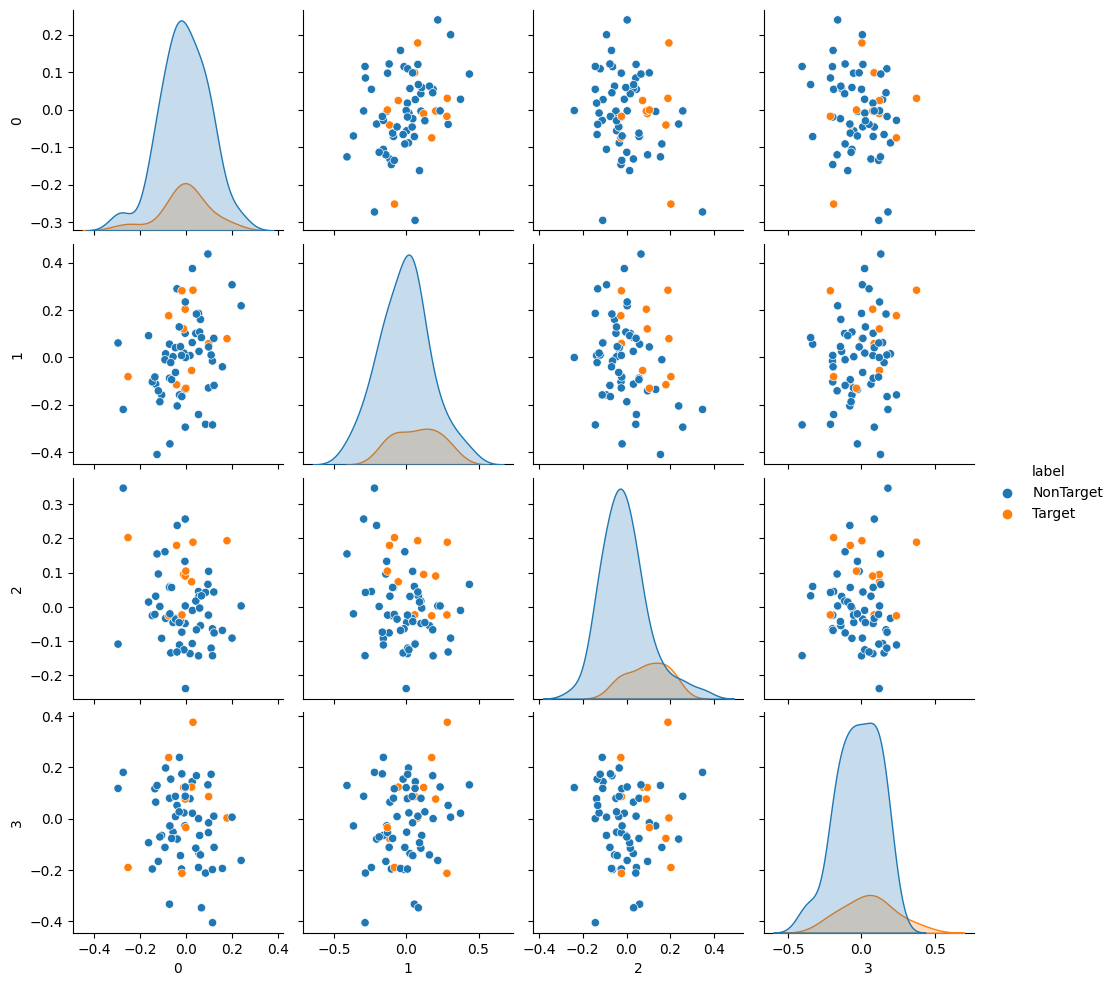

In [19]:
import seaborn as sns
import pandas as pd

n_features = Xt_train.shape[-1]
df_train = pd.DataFrame(Xt_train[:,feature_order[:4]])
df_train['label'] = y_train
g = sns.pairplot(df_train, hue='label')

In [20]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

1.0

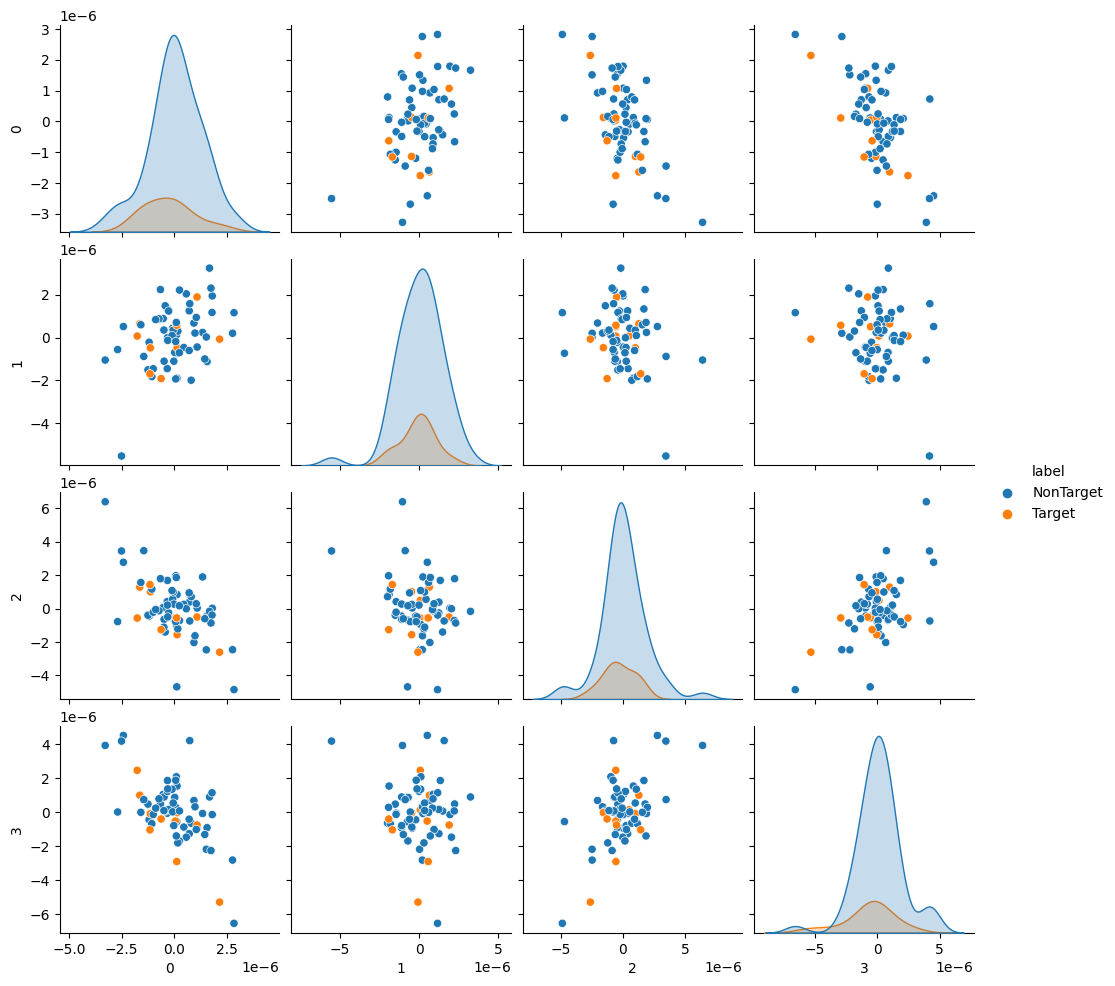

In [21]:
df_test = pd.DataFrame(Xt_test[:,feature_order[:4]])
df_test['label'] = y_test
g = sns.pairplot(df_test, hue='label')

In [22]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.6931818181818182